In [12]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import DataPreprocessor
from src.feature_engineering import FeatureEngineer
from src.graph_builder import GraphBuilder
from src.bottleneck_analysis import BottleneckAnalyzer

In [14]:
DATA_PATH = "../data/raw/delivery_data.csv"

preprocessor = DataPreprocessor(DATA_PATH)

engineer = FeatureEngineer()

graph_builder = GraphBuilder()

analyzer = BottleneckAnalyzer()

df = preprocessor.load_data()

df = preprocessor.clean_data(df)

df = engineer.create_temporal_features(df)

df = engineer.create_targets(df)

Loaded dataset shape: (144867, 24)


In [15]:
corridor_df = engineer.build_corridor_features(df)

print(corridor_df.head())


  source_center destination_center  mean_delay_ratio  delay_variance  \
0  IND000000AAL       IND411033AAA          2.678377        1.291174   
1  IND000000AAQ       IND700028AAB          6.285714        3.835948   
2  IND000000AAS       IND783370AAC          1.924721        0.200800   
3  IND000000AAZ       IND444203AAA          4.531673        1.998161   
4  IND000000AAZ       IND444303AAA          3.347826        1.275992   

   avg_distance  avg_actual_time  sla_breach_rate  trip_count  
0     20.911341        63.702703              1.0          37  
1     12.518075        78.250000              1.0           4  
2     36.861711        50.555556              1.0          18  
3     52.518967       181.666667              1.0           3  
4     45.696067       122.333333              1.0           3  


In [16]:

G = graph_builder.build_graph(corridor_df)

metrics_df = graph_builder.compute_graph_metrics(G)

In [17]:
top_hubs = analyzer.rank_hubs(metrics_df)

print(top_hubs.head(10))


             node  in_degree  out_degree  betweenness  pagerank  \
25   IND000000ACB         45          49     0.217920  0.010137   
12   IND562132AAA         36          35     0.124277  0.009038   
61   IND421302AAG         29          29     0.067737  0.006479   
24   IND160002AAC         32          29     0.054453  0.008805   
64   IND501359AAE         30          27     0.092168  0.008412   
102  IND110037AAM         21          24     0.040555  0.005182   
67   IND712311AAA         22          22     0.088498  0.006706   
47   IND131028AAB         20          20     0.047591  0.005589   
1    IND411033AAA         23          20     0.043013  0.006306   
66   IND600056AAB         18          18     0.041935  0.004226   

     bottleneck_score  
25          14.790209  
12          10.552422  
61           8.729038  
24           8.724423  
64           8.139391  
102          7.217777  
67           6.637411  
47           6.020713  
1            6.019097  
66           5.418042 

In [18]:
top_corridors = analyzer.rank_corridors(
    corridor_df
)

print(top_corridors.head(10))

     source_center destination_center  mean_delay_ratio  delay_variance  \
1797  IND571105AAA       IND571114AAA          4.804167       23.176701   
1870  IND580002AAA       IND580028AAA          4.979167       17.750868   
2722  IND847223AAA       IND842001AAA          6.733670       14.155116   
1593  IND521225AAB       IND521165AAA          4.682112       16.469347   
1586  IND521165AAA       IND521225AAB          5.722483       14.034274   
492   IND221010AAB       IND233001AAA          6.015460       13.171233   
2232  IND695101AAB       IND695012AAA          4.335829       14.891462   
294   IND147101AAA       IND160002AAC          5.843750       12.507558   
2672  IND841101AAA       IND841207AAB          4.714815       13.773621   
101   IND110037AAM       IND110064AAA          4.325000       13.706719   

      avg_distance  avg_actual_time  sla_breach_rate  trip_count  \
1797     27.143200       116.000000              1.0           2   
1870     23.839300       112.500000   

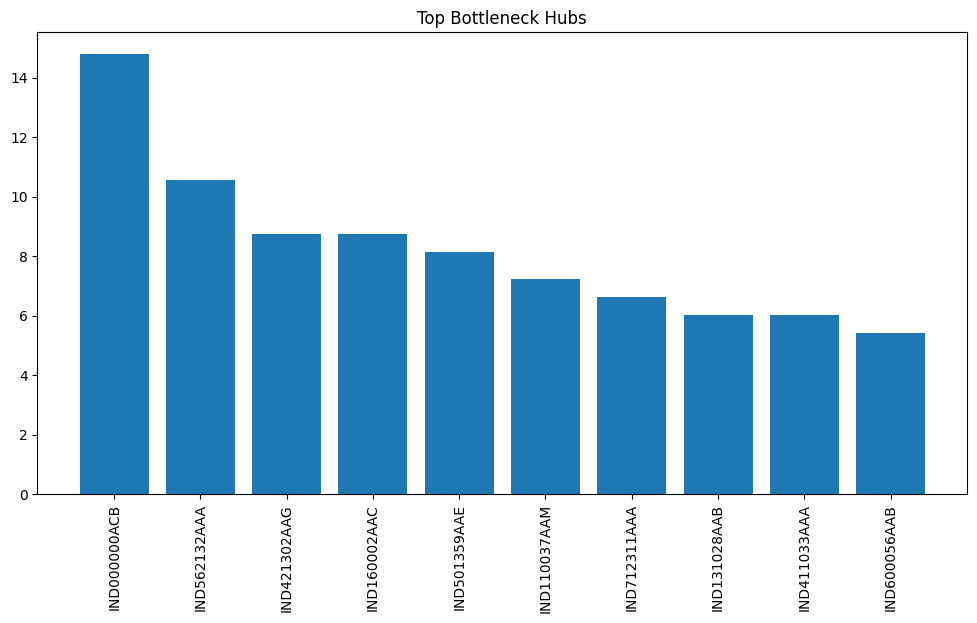

In [19]:
plt.figure(figsize=(12,6))

plt.bar(
    top_hubs["node"].astype(str).head(10),
    top_hubs["bottleneck_score"].head(10)
)

plt.xticks(rotation=90)

plt.title("Top Bottleneck Hubs")

plt.show()

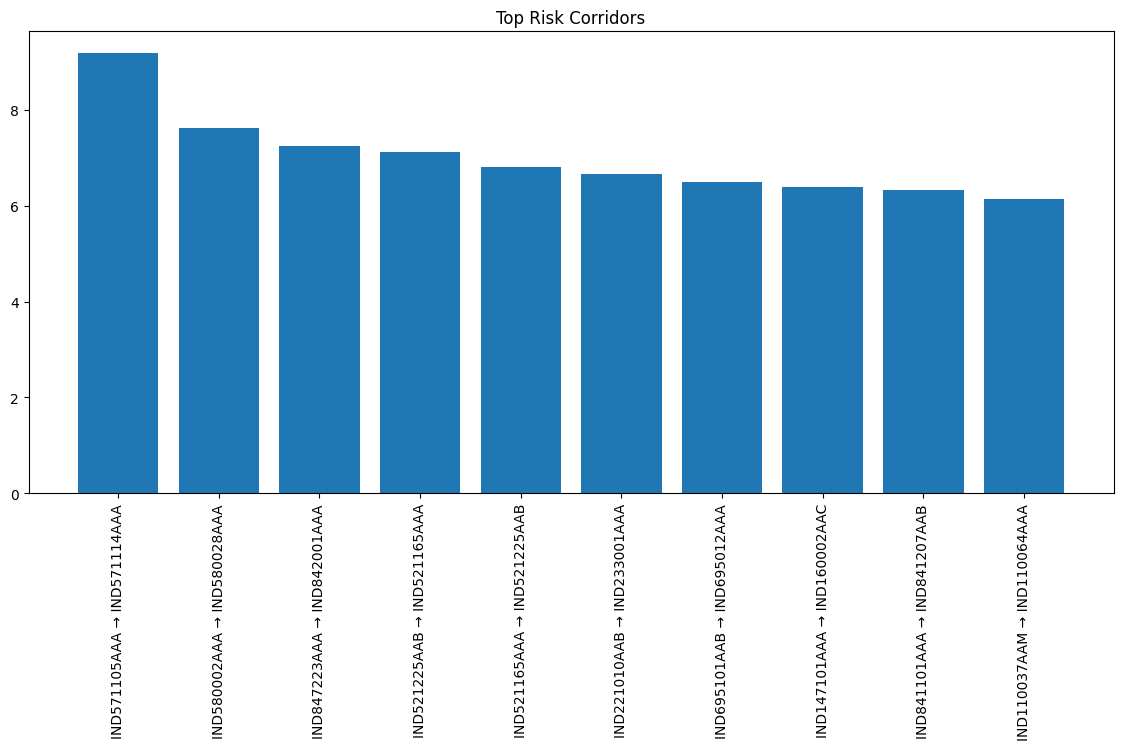

In [20]:
top_corridors["corridor"] = (
    top_corridors["source_center"].astype(str)
    + " → "
    + top_corridors["destination_center"].astype(str)
)

plt.figure(figsize=(14,6))

plt.bar(
    top_corridors["corridor"].head(10),
    top_corridors["corridor_risk"].head(10)
)

plt.xticks(rotation=90)

plt.title("Top Risk Corridors")

plt.show()

In [21]:
top_hubs.to_csv(
    "../outputs/reports/top_hubs.csv",
    index=False
)

top_corridors.to_csv(
    "../outputs/reports/top_corridors.csv",
    index=False
)

print("Bottleneck Analysis Completed")

Bottleneck Analysis Completed
